In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score


df1 = pd.read_csv("Data_Mining (3).csv")
df1.head()

,Planet Name,Planet Radius,Planet mass,gravity,Orbital period,orbital eccentricity,surface temperature,st_rad,star_mass,star Temperature,star luminosity,distance from star,ESI
0,11 Com b,NaN,4914.898486,NaN,323.21000,0.238,NaN,13.76,2.09,4874.0,NaN,1.178,NaN
1,11 Com b,NaN,6165.600000,NaN,326.03000,0.231,NaN,19.00,2.70,4742.0,NaN,1.290,NaN
2,11 Com b,NaN,5434.700000,NaN,NaN,NaN,NaN,NaN,2.60,NaN,NaN,1.210,NaN
3,11 UMi b,NaN,3337.070000,NaN,516.22000,0.080,NaN,24.08,1.80,4340.0,NaN,1.540,NaN
4,11 UMi b,NaN,4684.814200,NaN,516.21997,0.080,NaN,29.79,2.78,4213.0,NaN,1.530,NaN


Filling missing values
- In Planet mass and Planet Radius using Linear Regression
- In Orbital eccentricity, Distance from star, Surface Temperature, star Temperature, star luminosity, gravity, Orbital period using physics formulae

In [51]:
df1 = pd.read_csv("Data_Mining (3).csv")


train_data = df1[['Planet mass', 'Planet Radius']].dropna()

X = train_data[['Planet mass']]
y = train_data['Planet Radius']

model = LinearRegression()
model.fit(X, y)

missing_radius = df1[(df1['Planet Radius'].isna()) & (df1['Planet mass'].notna())]

df1.loc[missing_radius.index, 'Planet Radius'] = model.predict(missing_radius[['Planet mass']])

df1['Planet Radius'].fillna(df1['Planet Radius'].median())

df1.to_csv("updated_dataset.csv", index=False)


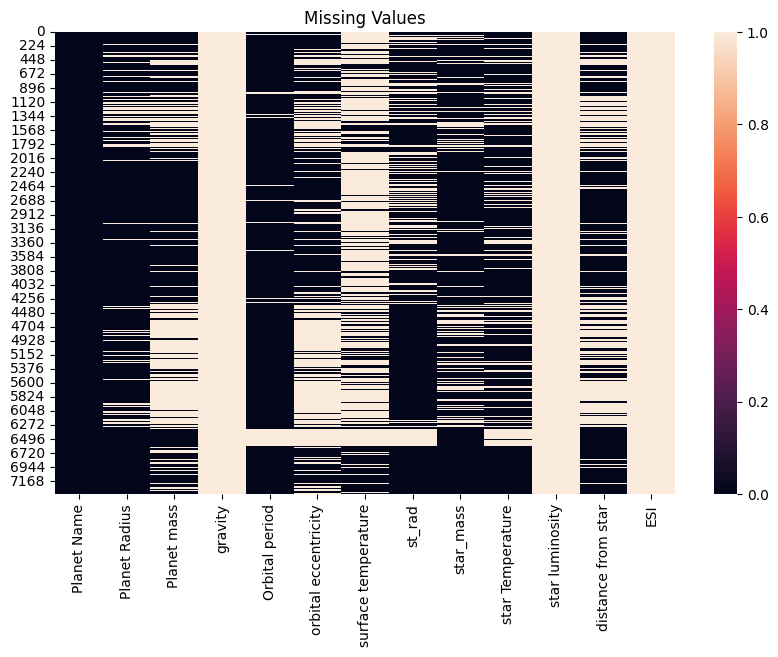

In [52]:
plt.figure(figsize=(10,6))
sns.heatmap(df1.isnull())
plt.title("Missing Values")
plt.show()

In [53]:
numeric_data = df1.select_dtypes(include=['number'])

corr = numeric_data.corr()

corr

,Planet Radius,Planet mass,gravity,Orbital period,orbital eccentricity,surface temperature,st_rad,star_mass,star Temperature,star luminosity,distance from star,ESI
Planet Radius,1.000000,0.752418,NaN,0.012160,0.229198,0.576789,0.291062,0.380847,0.337272,NaN,0.077127,NaN
Planet mass,0.752418,1.000000,NaN,0.014460,0.308959,0.319732,0.451612,0.271170,0.127876,NaN,0.104288,NaN
gravity,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Orbital period,0.012160,0.014460,NaN,1.000000,0.165656,-0.023447,-0.004087,-0.015804,-0.023145,NaN,0.999502,NaN
orbital eccentricity,0.229198,0.308959,NaN,0.165656,1.000000,-0.153705,0.064161,0.068540,0.113144,NaN,0.236675,NaN
surface temperature,0.576789,0.319732,NaN,-0.023447,-0.153705,1.000000,0.593486,0.607302,0.587680,NaN,0.072014,NaN
st_rad,0.291062,0.451612,NaN,-0.004087,0.064161,0.593486,1.000000,0.432153,-0.042153,NaN,-0.005411,NaN
star_mass,0.380847,0.271170,NaN,-0.015804,0.068540,0.607302,0.432153,1.000000,0.425865,NaN,-0.006602,NaN
star Temperature,0.337272,0.127876,NaN,-0.023145,0.113144,0.587680,-0.042153,0.425865,1.000000,NaN,-0.016189,NaN
star luminosity,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [54]:
missing_mass = df1[df1['Planet mass'].isna() & df1['Planet Radius'].notna()]
missing_mass.head()


,Planet Name,Planet Radius,Planet mass,gravity,Orbital period,orbital eccentricity,surface temperature,st_rad,star_mass,star Temperature,star luminosity,distance from star,ESI
37,2MASS J01225093-2439505 b,11.209000,NaN,NaN,NaN,NaN,1600.00,0.366450,0.353185,3309.0,NaN,NaN,NaN
120,55 Cnc e,2.023112,NaN,NaN,0.736546,NaN,1831.27,0.963515,NaN,5250.0,NaN,NaN,NaN
128,55 Cnc e,1.856000,NaN,NaN,0.736543,NaN,NaN,0.943000,0.905000,5272.0,NaN,NaN,NaN
193,AU Mic b,4.026926,NaN,NaN,8.453678,NaN,754.62,0.698009,NaN,3588.0,NaN,NaN,NaN
194,AU Mic b,3.550000,NaN,NaN,NaN,NaN,NaN,0.750000,0.500000,3700.0,NaN,0.0654,NaN


In [55]:
df2 = pd.read_csv("updated_dataset.csv")

train_data = df2[['Planet mass', 'Planet Radius']].dropna()

X = train_data[['Planet Radius']]
y = train_data['Planet mass']

model = LinearRegression()
model.fit(X, y)

missing_radius = df2[(df2['Planet mass'].isna()) & (df2['Planet Radius'].notna())]

df2.loc[missing_radius.index, 'Planet mass'] = model.predict(missing_radius[['Planet Radius']])

df2['Planet mass'] = df2['Planet mass'].abs()
df2 = df2[df2['Planet Radius'].notna()]

In [56]:
missing_OE = df2[df2['orbital eccentricity'].isna()]
df2['orbital eccentricity'] = df2['orbital eccentricity'].fillna(0.5)

# gravity is directly proportional to M / R**2

missing_gravity = df2[df2['gravity'].isna()]
df2.loc[missing_gravity.index, 'gravity'] = (
    df2.loc[missing_gravity.index, 'Planet mass'] /
    (df2.loc[missing_gravity.index, 'Planet Radius'] ** 2)
).round(5)


In [57]:
# T**2 is directly proportional to a**3

missing_dfs = df2[df2['distance from star'].isna()].index

df2.loc[missing_dfs, 'distance from star'] = (
    df2.loc[missing_dfs, 'Orbital period']**(2/3)
).round(5)

In [58]:
# T**2 is directly proportional to a**3

missing_OP = df2[df2['Orbital period'].isna()]

df2.loc[missing_OP.index, 'Orbital period'] = (
    df2.loc[missing_OP.index, 'distance from star']**(3/2)
)

In [59]:
# ST is directly proportional to StarT*sqrt(SR/2*a*215.032)

missing_ST = df2[df2['surface temperature'].isna()]

df2.loc[missing_ST.index, 'surface temperature'] = df2.loc[missing_ST.index, 'star Temperature'] * np.sqrt(
    df2.loc[missing_ST.index, 'st_rad'] / (2 * df2.loc[missing_ST.index, 'distance from star'] * 215.032)
).round(4)

In [60]:
df2['surface temperature'] = df2['surface temperature'].bfill()
df2['st_rad'] = df2['st_rad'].bfill()
df2['star Temperature'] = df2['star Temperature'].ffill()

df2 = df2.dropna(subset=['Orbital period'])

df2 = df2.drop('star luminosity', axis=1)

df2['star_mass'] = df2['star_mass'].fillna(2.098)

In [61]:
df2['density'] = df2['Planet mass'] / (df2['Planet Radius'] ** 3)
df2.head(3)

,Planet Name,Planet Radius,Planet mass,gravity,Orbital period,orbital eccentricity,surface temperature,st_rad,star_mass,star Temperature,distance from star,ESI,density
0,11 Com b,20.097158,4914.898486,12.16873,323.210,0.238,803.2352,13.76,2.09,4874.0,1.178,NaN,0.605495
1,11 Com b,23.326806,6165.600000,11.33091,326.030,0.231,877.7442,19.00,2.70,4742.0,1.290,NaN,0.485746
2,11 Com b,21.439426,5434.700000,11.82359,1.331,0.500,827.6380,24.08,2.60,4742.0,1.210,NaN,0.551488


In [62]:
import numpy as np

# weights
w_r, w_m, w_d, w_g, w_t, w_dist, w_star_t, w_star_m = 0.57, 0.8, 1.07, 0.5, 5.58, 0.5, 0.3, 0.3
n = 8

# Earth reference values
r0, m0, d0, g0 = 1, 1, 1, 1
t0, dist0 = 288, 1
star_t0, star_m0 = 5778, 1

# compute similarities for entire dataframe
r_sim = (1 - abs((df2['Planet Radius'] - r0) / (df2['Planet Radius'] + r0)))**w_r

m_sim = (1 - abs((df2['Planet mass'] - m0) / (df2['Planet mass'] + m0)))**w_m

d_sim = (1 - abs((df2['density'] - d0) / (df2['density'] + d0)))**w_d

g_sim = (1 - abs((df2['gravity'] - g0) / (df2['gravity'] + g0)))**w_g

t_sim = (1 - abs((df2['surface temperature'] - t0) / (df2['surface temperature'] + t0)))**w_t

dist_sim = (1 - abs((df2['distance from star'] - dist0) / (df2['distance from star'] + dist0)))**w_dist

star_t_sim = (1 - abs((df2['star Temperature'] - star_t0) / (df2['star Temperature'] + star_t0)))**w_star_t

star_m_sim = (1 - abs((df2['star_mass'] - star_m0) / (df2['star_mass'] + star_m0)))**w_star_m

# compute ESI
df2['ESI'] = (
    r_sim * m_sim * d_sim * g_sim * 
    t_sim * dist_sim * star_t_sim * star_m_sim
) ** (1/n)

# round values
df2['ESI'] = df2['ESI'].round(5)

# check result
print(df2[['Planet Name', 'ESI']].head())

  Planet Name      ESI
0    11 Com b  0.20706
1    11 Com b  0.18655
2    11 Com b  0.19828
3    11 UMi b  0.21755
4    11 UMi b  0.19353


In [63]:
df2.to_csv("updated_dataset2.csv", index=False)

In [64]:
def classify_planet(radius):
    if radius < 0.8:
        return "Subterran"
    elif radius < 1.25:
        return "Terran"
    elif radius < 2.0:
        return "Superterran"
    elif radius < 6.0:
        return "Neptunian"
    else:
        return "Jovian"

df2['planet_type'] = df2['Planet Radius'].apply(classify_planet)

df2.head()

,Planet Name,Planet Radius,Planet mass,gravity,Orbital period,orbital eccentricity,surface temperature,st_rad,star_mass,star Temperature,distance from star,ESI,density,planet_type
0,11 Com b,20.097158,4914.898486,12.16873,323.21000,0.238,803.2352,13.76,2.09,4874.0,1.178,0.20706,0.605495,Jovian
1,11 Com b,23.326806,6165.600000,11.33091,326.03000,0.231,877.7442,19.00,2.70,4742.0,1.290,0.18655,0.485746,Jovian
2,11 Com b,21.439426,5434.700000,11.82359,1.33100,0.500,827.6380,24.08,2.60,4742.0,1.210,0.19828,0.551488,Jovian
3,11 UMi b,16.022781,3337.070000,12.99839,516.22000,0.080,827.6380,24.08,1.80,4340.0,1.540,0.21755,0.811244,Jovian
4,11 UMi b,19.503019,4684.814200,12.31654,516.21997,0.080,896.5264,29.79,2.78,4213.0,1.530,0.19353,0.631520,Jovian


In [65]:
df2.isnull().sum()

Planet Name             0
Planet Radius           0
Planet mass             0
gravity                 0
Orbital period          0
orbital eccentricity    0
surface temperature     0
st_rad                  0
star_mass               0
star Temperature        0
distance from star      0
ESI                     0
density                 0
planet_type             0
dtype: int64

- EDA
  - Visualizing the data using Correlation and Dissimilarity matrix

In [66]:
data = pd.read_csv("updated_dataset2.csv")

numeric_data = data.select_dtypes(include=['number'])

corr = numeric_data.corr()

corr

,Planet Radius,Planet mass,gravity,Orbital period,orbital eccentricity,surface temperature,st_rad,star_mass,star Temperature,distance from star,ESI,density
Planet Radius,1.000000,0.632639,-0.356534,0.011132,-0.099555,0.242061,0.245617,0.189864,0.290291,0.072519,-0.104645,-0.247846
Planet mass,0.632639,1.000000,0.036693,0.011847,0.204174,0.052949,0.263639,0.240387,0.106293,0.103259,-0.297998,0.023138
gravity,-0.356534,0.036693,1.000000,-0.003674,0.222053,-0.074180,-0.072740,0.031810,-0.185779,-0.012942,-0.385796,0.948183
Orbital period,0.011132,0.011847,-0.003674,1.000000,0.010970,-0.005415,-0.003754,-0.015113,-0.022567,0.446412,-0.008329,-0.002691
orbital eccentricity,-0.099555,0.204174,0.222053,0.010970,1.000000,-0.131201,-0.054040,0.151209,0.026757,0.033950,-0.251747,0.140246
surface temperature,0.242061,0.052949,-0.074180,-0.005415,-0.131201,1.000000,0.071062,0.113523,0.249300,0.023402,-0.379941,-0.045494
st_rad,0.245617,0.263639,-0.072740,-0.003754,-0.054040,0.071062,1.000000,0.245716,-0.009009,0.016201,-0.029182,-0.052649
star_mass,0.189864,0.240387,0.031810,-0.015113,0.151209,0.113523,0.245716,1.000000,0.233910,0.009269,-0.243397,0.008825
star Temperature,0.290291,0.106293,-0.185779,-0.022567,0.026757,0.249300,-0.009009,0.233910,1.000000,0.106109,-0.073112,-0.154858
distance from star,0.072519,0.103259,-0.012942,0.446412,0.033950,0.023402,0.016201,0.009269,0.106109,1.000000,-0.054509,-0.009841


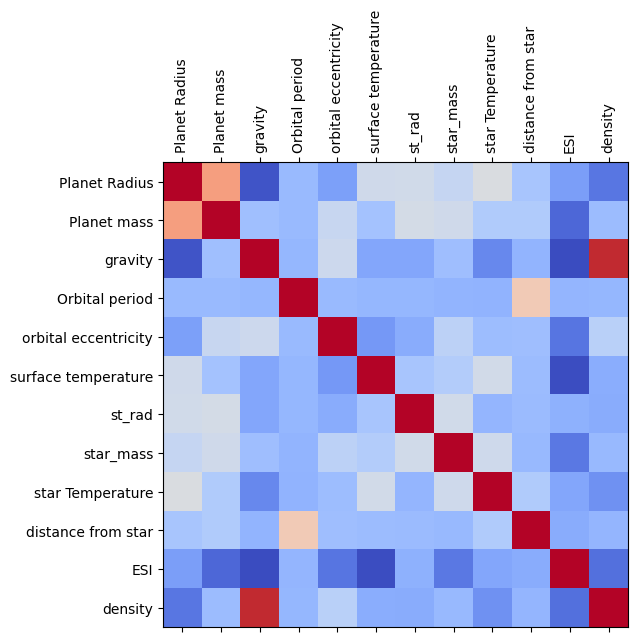

In [67]:
fig = plt.figure(figsize = (6,6))
plt.matshow(corr, cmap='coolwarm', fignum = fig.number)
plt.xticks(range(len(corr.columns)), corr.columns, rotation = 'vertical');
plt.yticks(range(len(corr.columns)), corr.columns);

In [68]:
diss = 1-corr
diss

,Planet Radius,Planet mass,gravity,Orbital period,orbital eccentricity,surface temperature,st_rad,star_mass,star Temperature,distance from star,ESI,density
Planet Radius,0.000000,0.367361,1.356534,0.988868,1.099555,0.757939,0.754383,0.810136,0.709709,0.927481,1.104645,1.247846
Planet mass,0.367361,0.000000,0.963307,0.988153,0.795826,0.947051,0.736361,0.759613,0.893707,0.896741,1.297998,0.976862
gravity,1.356534,0.963307,0.000000,1.003674,0.777947,1.074180,1.072740,0.968190,1.185779,1.012942,1.385796,0.051817
Orbital period,0.988868,0.988153,1.003674,0.000000,0.989030,1.005415,1.003754,1.015113,1.022567,0.553588,1.008329,1.002691
orbital eccentricity,1.099555,0.795826,0.777947,0.989030,0.000000,1.131201,1.054040,0.848791,0.973243,0.966050,1.251747,0.859754
surface temperature,0.757939,0.947051,1.074180,1.005415,1.131201,0.000000,0.928938,0.886477,0.750700,0.976598,1.379941,1.045494
st_rad,0.754383,0.736361,1.072740,1.003754,1.054040,0.928938,0.000000,0.754284,1.009009,0.983799,1.029182,1.052649
star_mass,0.810136,0.759613,0.968190,1.015113,0.848791,0.886477,0.754284,0.000000,0.766090,0.990731,1.243397,0.991175
star Temperature,0.709709,0.893707,1.185779,1.022567,0.973243,0.750700,1.009009,0.766090,0.000000,0.893891,1.073112,1.154858
distance from star,0.927481,0.896741,1.012942,0.553588,0.966050,0.976598,0.983799,0.990731,0.893891,0.000000,1.054509,1.009841


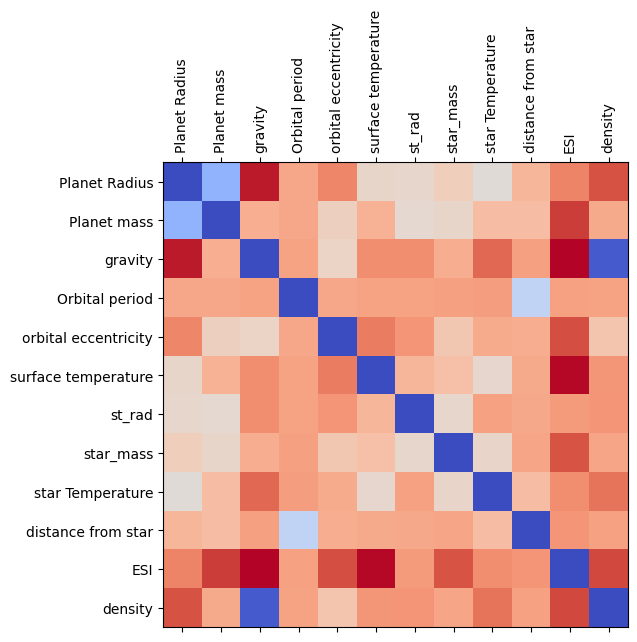

In [69]:
fig = plt.figure(figsize = (6,6))
plt.matshow(diss, cmap='coolwarm', fignum = fig.number)
plt.xticks(range(len(corr.columns)), diss.columns, rotation = 'vertical');
plt.yticks(range(len(corr.columns)), diss.columns);

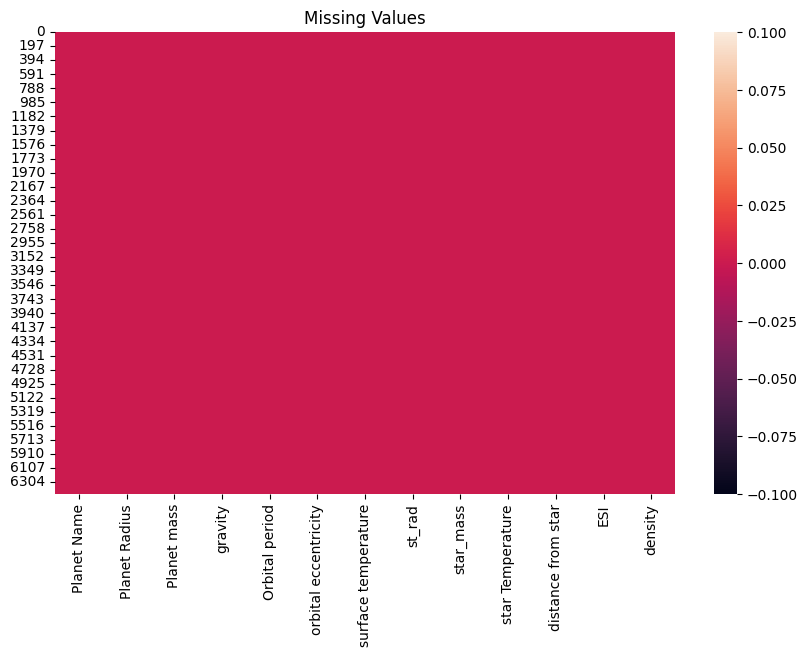

In [70]:
plt.figure(figsize=(10,6))
sns.heatmap(data.isnull())
plt.title("Missing Values")
plt.show()

- Classifing the planets according to their size


In [71]:
data.to_csv("updated_dataset3.csv", index=False)

In [72]:
data1 = pd.read_csv("updated_dataset3.csv")
data1.head(3)

,Planet Name,Planet Radius,Planet mass,gravity,Orbital period,orbital eccentricity,surface temperature,st_rad,star_mass,star Temperature,distance from star,ESI,density
0,11 Com b,20.097158,4914.898486,12.16873,323.210,0.238,803.2352,13.76,2.09,4874.0,1.178,0.20706,0.605495
1,11 Com b,23.326806,6165.600000,11.33091,326.030,0.231,877.7442,19.00,2.70,4742.0,1.290,0.18655,0.485746
2,11 Com b,21.439426,5434.700000,11.82359,1.331,0.500,827.6380,24.08,2.60,4742.0,1.210,0.19828,0.551488


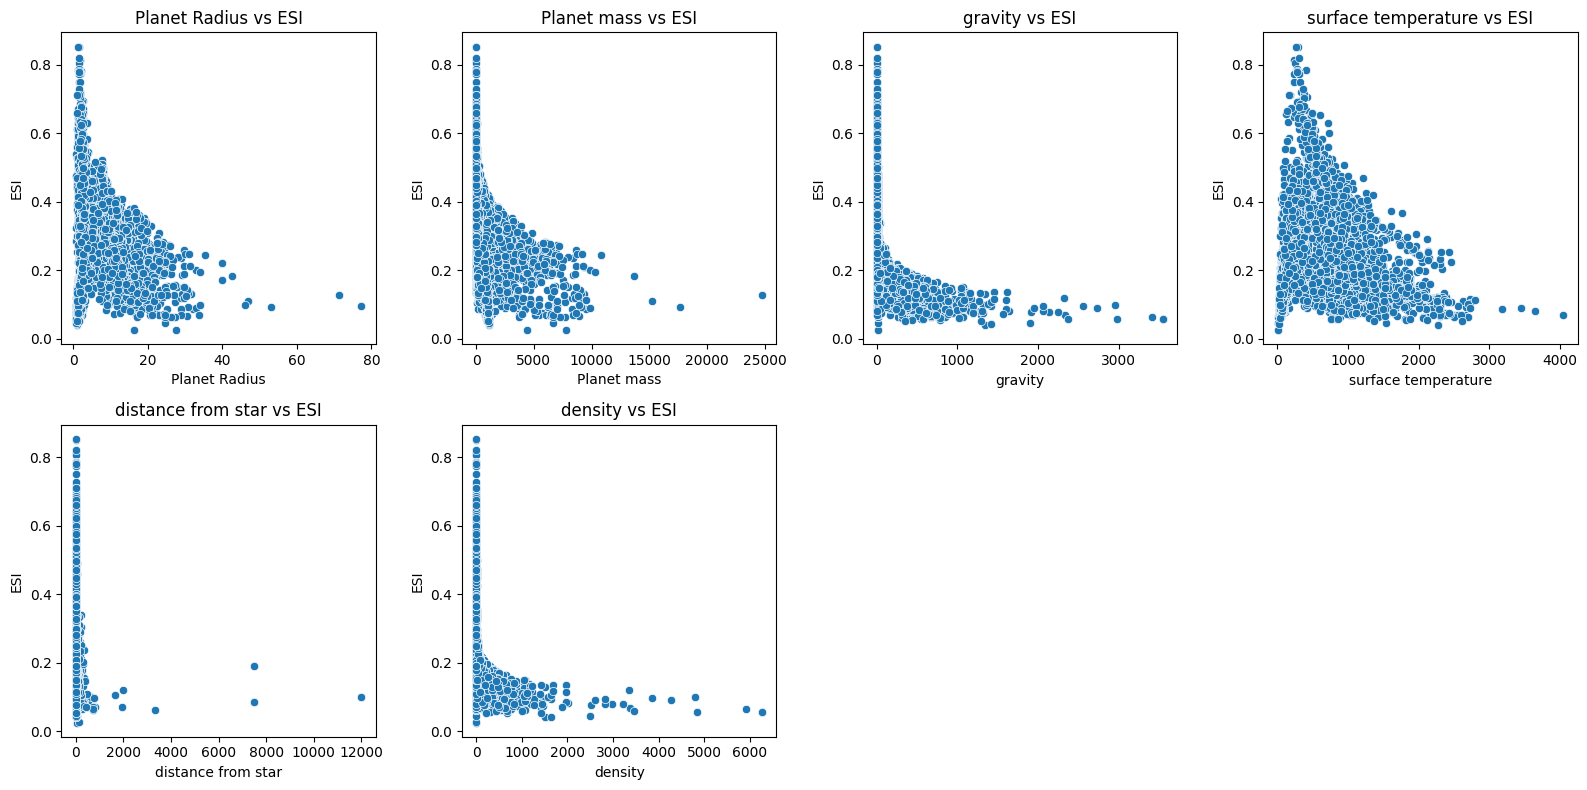

In [73]:
cols = ['Planet Radius', 'Planet mass', 'gravity',
        'surface temperature', 'distance from star', 'density']


rows = 2
cols_count = 4

fig, axes = plt.subplots(rows, cols_count, figsize=(16, 8))
axes = axes.flatten() 

for i, col in enumerate(cols):
    sns.scatterplot(x=data1[col], y=data1['ESI'], ax=axes[i])
    axes[i].set_title(f"{col} vs ESI")

for j in range(len(cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

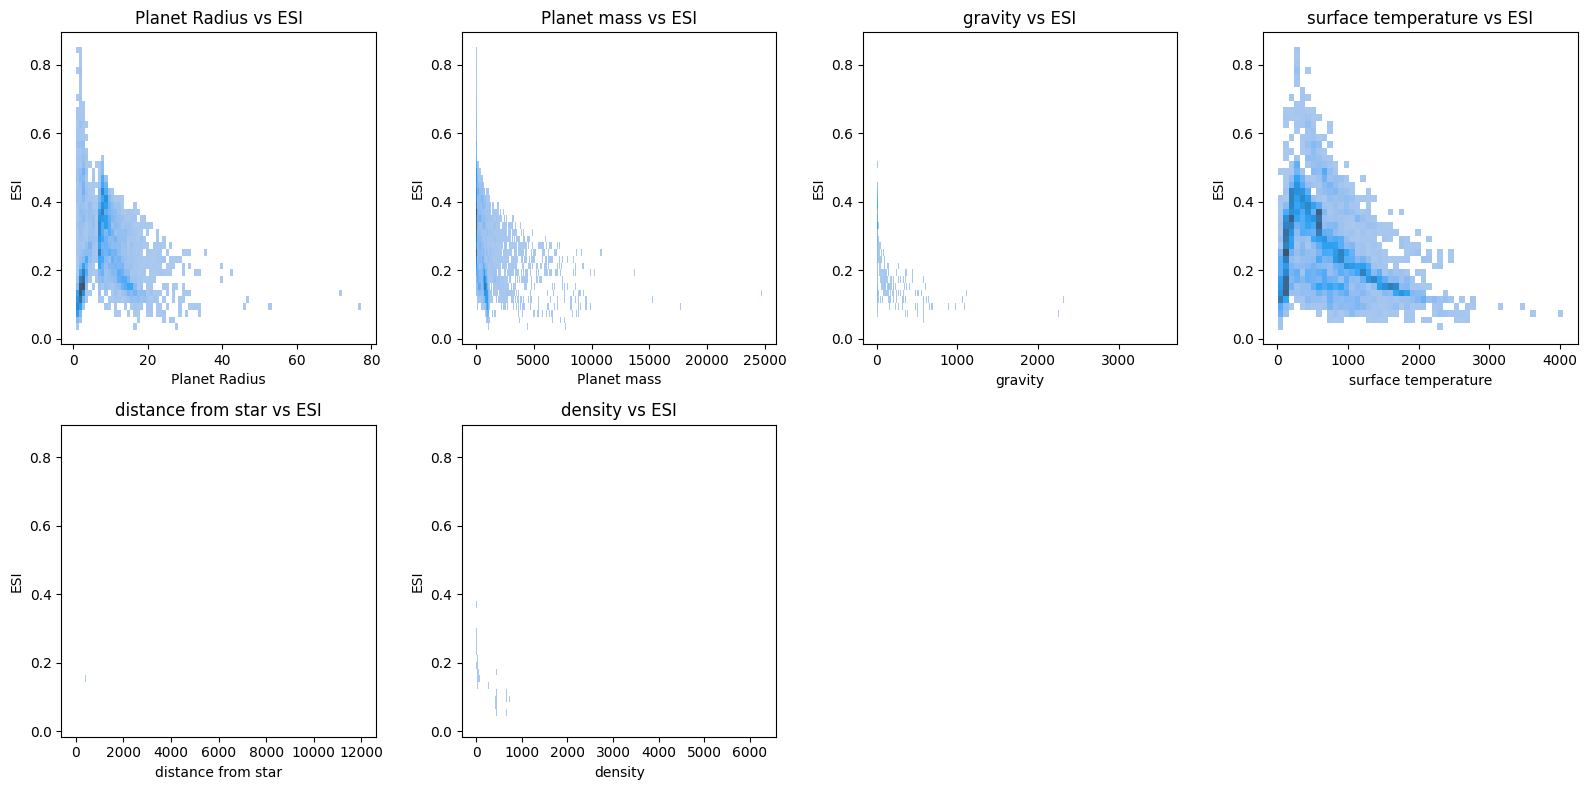

In [74]:
cols = ['Planet Radius', 'Planet mass', 'gravity',
        'surface temperature', 'distance from star', 'density']


rows = 2
cols_count = 4

fig, axes = plt.subplots(rows, cols_count, figsize=(16, 8))
axes = axes.flatten() 

for i, col in enumerate(cols):
    sns.histplot(x=data1[col], y=data1['ESI'], ax=axes[i])
    axes[i].set_title(f"{col} vs ESI")

for j in range(len(cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


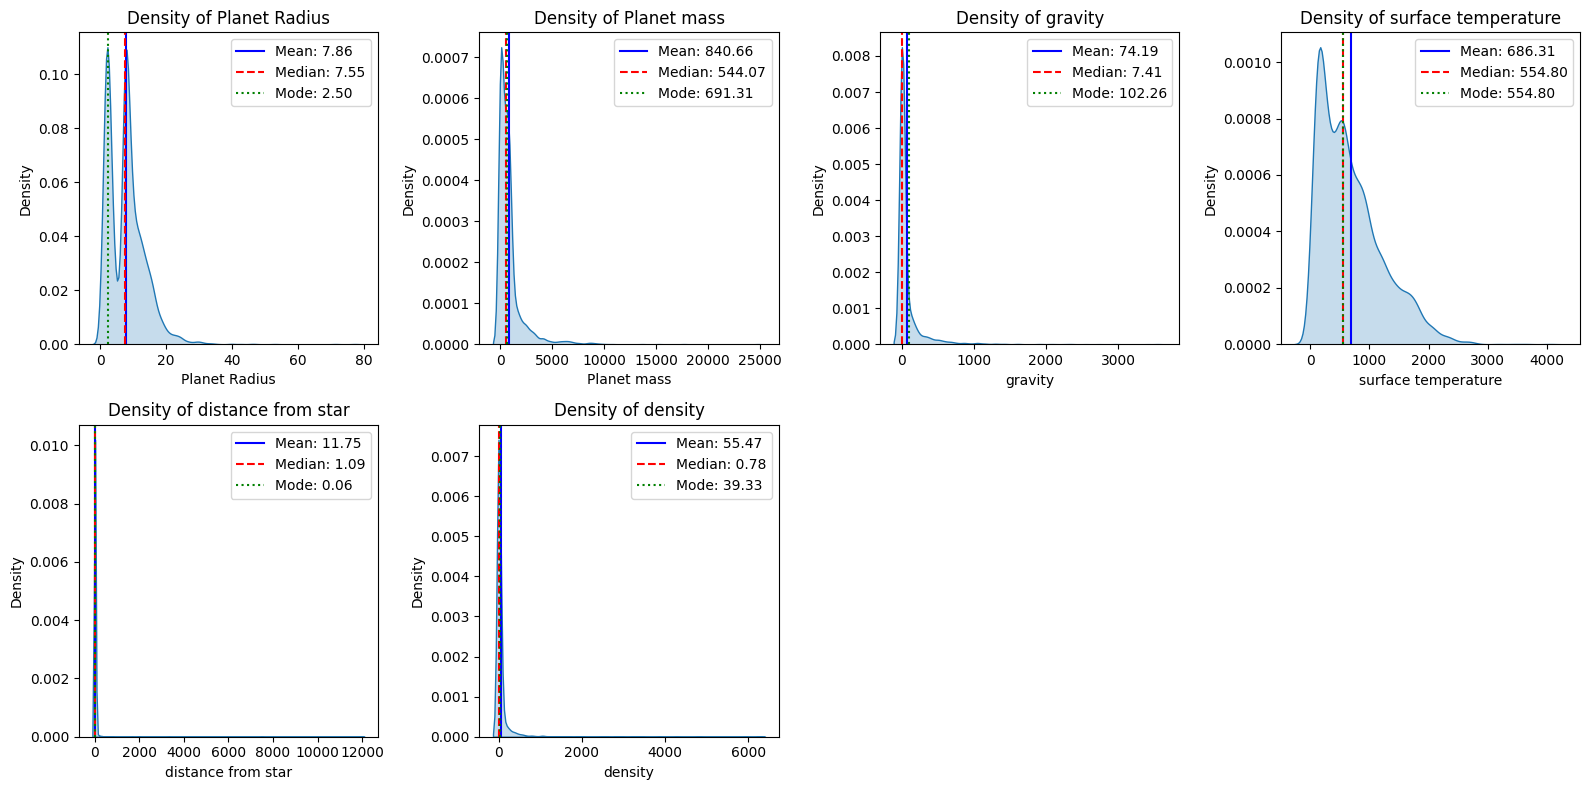

In [75]:
rows = 2
cols_count = 4

fig, axes = plt.subplots(rows, cols_count, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(cols):
    if data1[col].dtype != 'object': 
        
        sns.kdeplot(data1[col], fill=True, ax=axes[i])
        
        mean_val = data1[col].mean()
        median_val = data1[col].median()
        mode_val = data1[col].mode()[0]
        
        axes[i].axvline(mean_val, color='blue', label=f'Mean: {mean_val:.2f}')
        axes[i].axvline(median_val, color='red', linestyle='--', label=f'Median: {median_val:.2f}')
        axes[i].axvline(mode_val, color='green', linestyle=':', label=f'Mode: {mode_val:.2f}')
        
        axes[i].set_title(f"Density of {col}")
        axes[i].legend()
        
    else:
        axes[i].set_visible(False)

for j in range(len(cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

- Outliers detection and removing of outliers
- Using Box plots

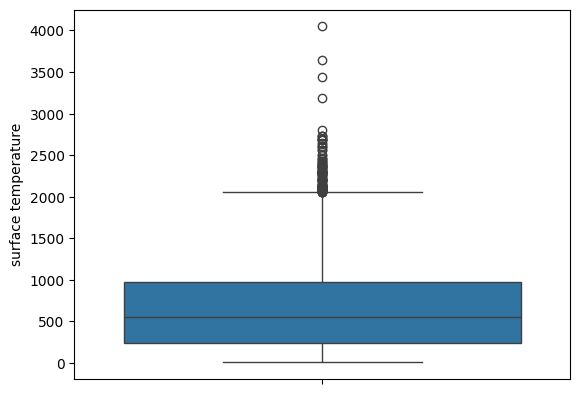

In [76]:
# Outliers in SUrface Temperature

sns.boxplot(data = data1['surface temperature'])
plt.show()

In [77]:
# Removal of Outliers in surface temperature

q1 = data1['surface temperature'].quantile(0.25)
q3 = data1['surface temperature'].quantile(0.75)

IQR = q3 - q1

IQR

np.float64(726.053675)

In [78]:
min_range = q1 - (1.5 * IQR)
max_range = q3 + (1.5 * IQR)
min_range, max_range
data1.shape

(6472, 13)

In [79]:
data1 = data1[data1['surface temperature']<= max_range]
data1.shape

(6362, 13)

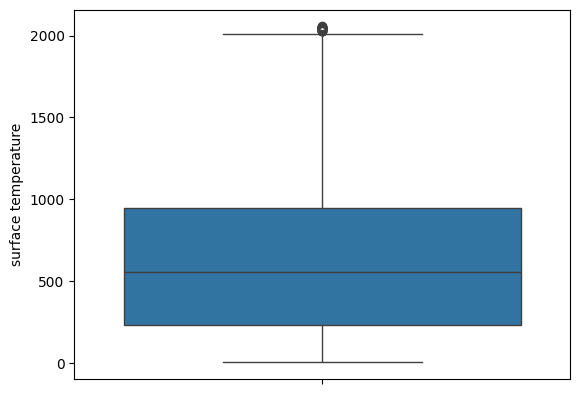

In [80]:

sns.boxplot(data = data1['surface temperature'])
plt.show()

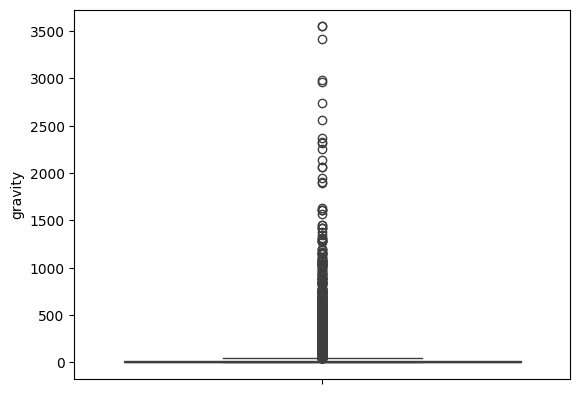

In [81]:
# Outliers in gravity

sns.boxplot(data = data1['gravity'])
plt.show()

In [82]:
q4 = data1['gravity'].quantile(0.25)
q5 = data1['gravity'].quantile(0.75)

IQR = q5 - q4

mini = q4 - (1.5 * IQR)
maxi = q5 + (1.5 * IQR)

data1 = data1[data1["gravity"] <= maxi]
data1.shape

(4919, 13)

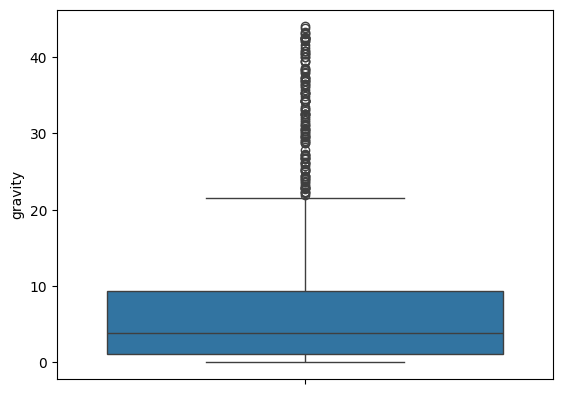

In [83]:
# After removing the outliers

sns.boxplot(data = data1['gravity'])
plt.show()

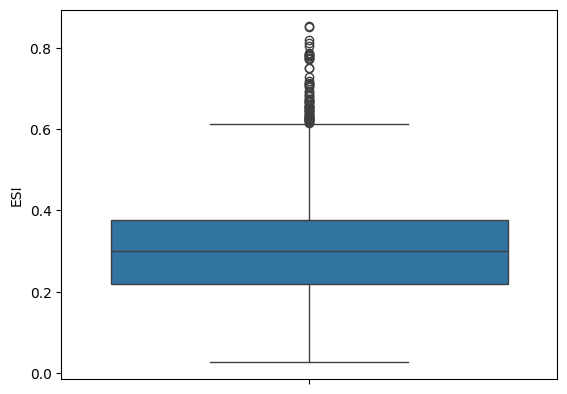

In [84]:
sns.boxplot(data = data1['ESI'])
plt.show()

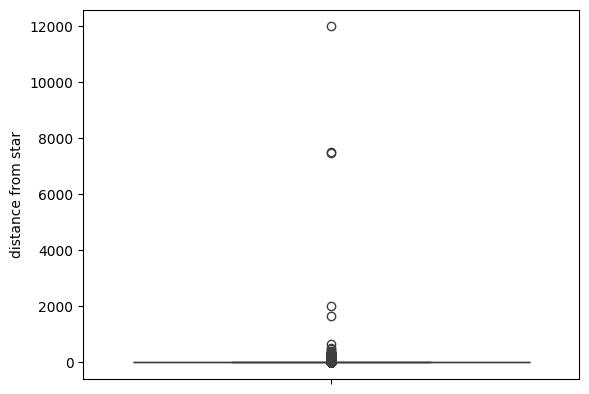

In [85]:
# Outliers in distance from star

sns.boxplot(data = data1['distance from star'])
plt.show()

In [86]:
q4 = data1['distance from star'].quantile(0.25)
q5 = data1['distance from star'].quantile(0.75)

IQR = q5 - q4

mini = q4 - (1.5 * IQR)
maxi = q5 + (1.5 * IQR)

data1 = data1[data1["distance from star"] <= maxi]
data1.shape

(4521, 13)

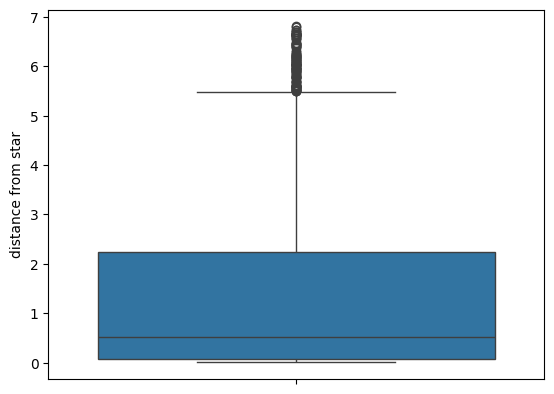

In [87]:
# Outliers in distance from star

sns.boxplot(data = data1['distance from star'])
plt.show()

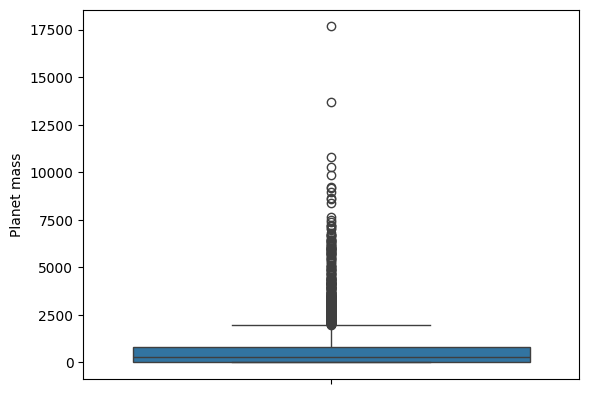

In [88]:
sns.boxplot(data = data1['Planet mass'])
plt.show()

In [89]:
q4 = data1['Planet mass'].quantile(0.25)
q5 = data1['Planet mass'].quantile(0.75)

IQR = q5 - q4

mini = q4 - (1.5 * IQR)
maxi = q5 + (1.5 * IQR)

data1 = data1[data1["Planet mass"] <= maxi]
data1.shape

(4074, 13)

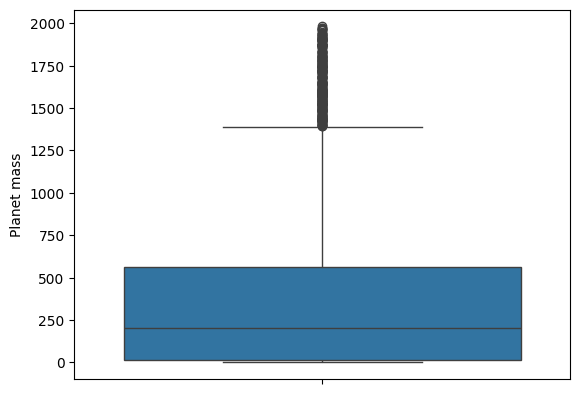

In [90]:
# After removing the outliers in planet mass

sns.boxplot(data = data1['Planet mass'])
plt.show()

In [91]:
(data1["ESI"] > 0.65).sum()

np.int64(41)

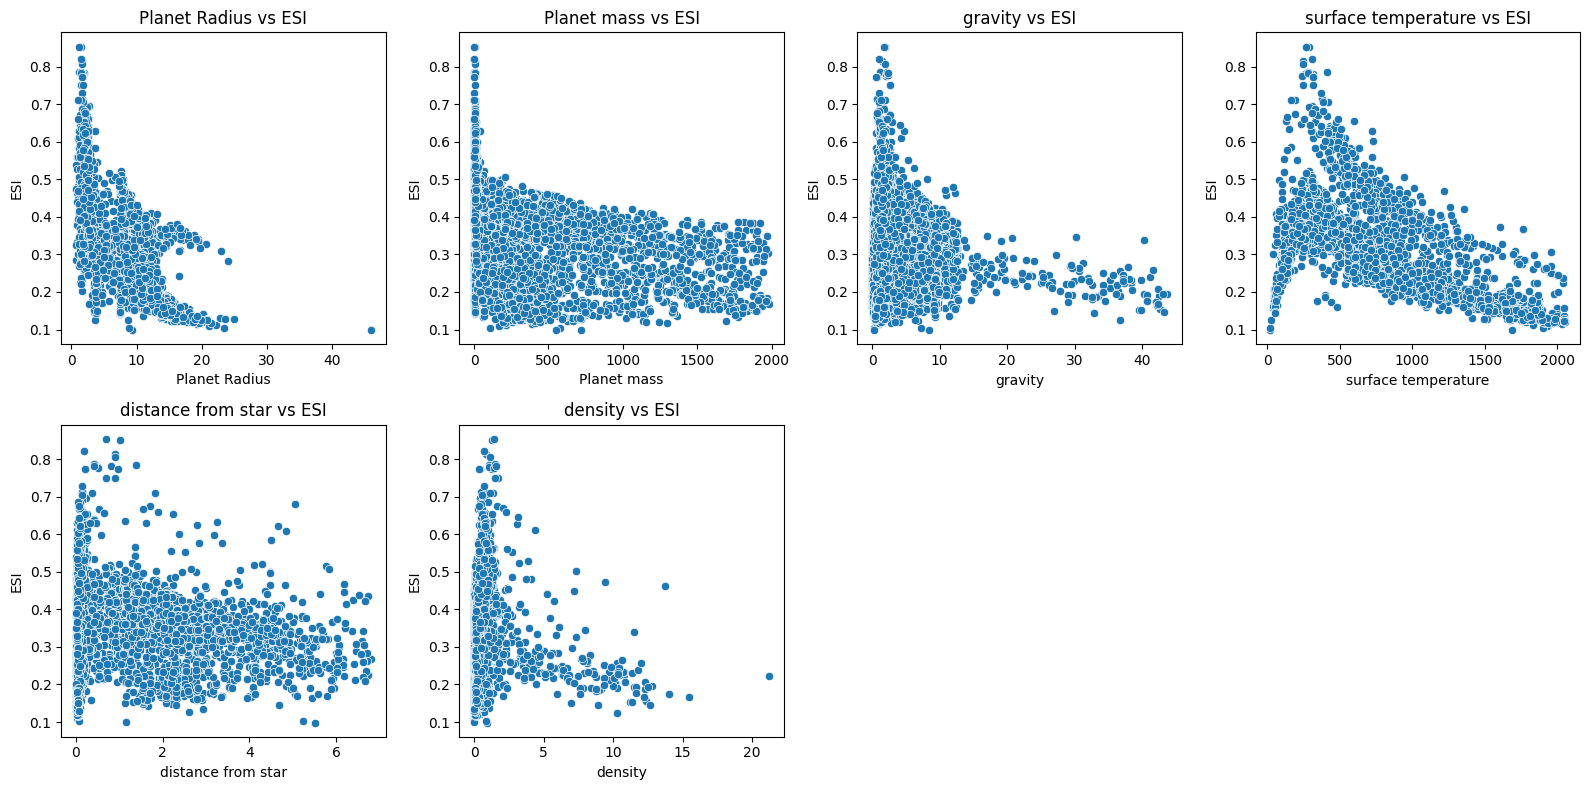

In [92]:
cols = ['Planet Radius', 'Planet mass', 'gravity',
        'surface temperature', 'distance from star', 'density']


rows = 2
cols_count = 4

fig, axes = plt.subplots(rows, cols_count, figsize=(16, 8))
axes = axes.flatten() 

for i, col in enumerate(cols):
    sns.scatterplot(x=data1[col], y=data1['ESI'], ax=axes[i])
    axes[i].set_title(f"{col} vs ESI")

for j in range(len(cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

- Apriori Algorithm
   - For Pattern Extraction
   - Attribute Rules Extraction


In [95]:
import pandas as pd
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

df = pd.read_csv("updated_dataset3.csv")



bins = [0, 0.6, 0.8, 1]
labels = ['low', 'medium', 'high']

df['esi_range'] = pd.cut(df['ESI'], bins=bins, labels=labels)

esi_range = {
    'low': '0 - 0.6',
    'medium': '0.6 - 0.8',
    'high': '0.8 - 1.0'
}

cols = [
    'Planet Radius', 'Planet mass', 'gravity',
    'Orbital period', 'orbital eccentricity',
    'surface temperature', 'distance from star',
    'density'
]


df_rounded = df.copy()


for esi in labels:
    subset = df_rounded[df_rounded['esi_range'] == esi]

    transactions = []

    for _, row in subset.iterrows():
        items = [f"{col}={row[col]}" for col in cols]
        transactions.append(items)

    te = TransactionEncoder()
    te_data = te.fit(transactions).transform(transactions)
    df_encoded = pd.DataFrame(te_data, columns=te.columns_)

    frequent_itemsets = apriori(df_encoded,
                               min_support=0.02,
                               use_colnames=True)

    print("\n")
    print(f"ESI = {esi.upper()}  (Range: {esi_range[esi]})")
    print("\n")

    if frequent_itemsets.empty:
        print("No frequent itemsets found")
        continue

    frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(len)
    top_sets = frequent_itemsets.sort_values(
        ['length', 'support'], ascending=[False, False]
    ).head(5)

    for _, row in top_sets.iterrows():
        items = ", ".join(row['itemsets'])
        print(f"{{ {items} }} → support = {row['support']:.3f}")



ESI = LOW  (Range: 0 - 0.6)


{ orbital eccentricity=0.5, surface temperature=554.8 } → support = 0.040
{ orbital eccentricity=0.5 } → support = 0.404
{ orbital eccentricity=0.0 } → support = 0.090
{ surface temperature=554.8 } → support = 0.041


ESI = MEDIUM  (Range: 0.6 - 0.8)


{ orbital eccentricity=0.0, gravity=0.92746, Planet Radius=1.193, surface temperature=129.67499999999998, Orbital period=0.5182331, density=0.7774144347533577, distance from star=0.64518, Planet mass=1.32 } → support = 0.029
{ density=0.52147027703529, Planet Radius=1.87, distance from star=0.1646, orbital eccentricity=0.063, gravity=0.97515, Orbital period=29.79749, surface temperature=467.0, Planet mass=3.41 } → support = 0.029
{ orbital eccentricity=0.0, gravity=0.92746, Planet Radius=1.193, Orbital period=0.5182331, density=0.7774144347533577, distance from star=0.64518, Planet mass=1.32 } → support = 0.029
{ gravity=0.92746, Planet Radius=1.193, surface temperature=129.67499999999998, Orbital period=0

In [96]:
df = pd.read_csv("updated_dataset3.csv")

bins = [0, 0.6, 0.8, 1]
labels = ['low', 'medium', 'high']

df['esi_range'] = pd.cut(df['ESI'], bins=bins, labels=labels)

cols = [
    'Planet Radius', 'Planet mass', 'gravity',
    'Orbital period', 'orbital eccentricity',
    'surface temperature', 'distance from star',
    'density'
]

df = df.dropna(subset=cols + ['esi_range'])

df_rounded = df.copy()
for col in cols:
    df_rounded[col] = df_rounded[col].round(1)


transactions = []

for _, row in df_rounded.iterrows():
    items = [f"{col}={row[col]}" for col in cols]
    
    items.append(f"ESI={row['esi_range']}")
    
    transactions.append(items)


te = TransactionEncoder()
te_data = te.fit(transactions).transform(transactions)
df_encoded = pd.DataFrame(te_data, columns=te.columns_)


frequent_itemsets = apriori(df_encoded,
                           min_support=0.02,
                           use_colnames=True)

rules = association_rules(frequent_itemsets,
                          metric="confidence",
                          min_threshold=0.5)

esi_rules = rules[
    rules['consequents'].astype(str).str.contains('ESI=')
]


print("\n           APRIORI RULES FOR ESI            \n")

for _, row in esi_rules.iterrows():
    antecedent = ", ".join(list(row['antecedents']))
    consequent = ", ".join(list(row['consequents']))
    
    print(f"IF {{ {antecedent} }}")
    print(f"THEN {{ {consequent} }}")
    print(f"Support: {row['support']:.3f}, Confidence: {row['confidence']:.3f}, Lift: {row['lift']:.3f}")
    print("\n")


           APRIORI RULES FOR ESI            

IF { Planet Radius=7.4 }
THEN { ESI=low }
Support: 0.084, Confidence: 1.000, Lift: 1.012


IF { Planet Radius=7.5 }
THEN { ESI=low }
Support: 0.031, Confidence: 1.000, Lift: 1.012


IF { density=0.0 }
THEN { ESI=low }
Support: 0.106, Confidence: 1.000, Lift: 1.012


IF { density=0.1 }
THEN { ESI=low }
Support: 0.097, Confidence: 1.000, Lift: 1.012


IF { density=0.2 }
THEN { ESI=low }
Support: 0.049, Confidence: 1.000, Lift: 1.012


IF { density=0.3 }
THEN { ESI=low }
Support: 0.040, Confidence: 0.992, Lift: 1.004


IF { density=0.4 }
THEN { ESI=low }
Support: 0.043, Confidence: 0.976, Lift: 0.987


IF { density=0.5 }
THEN { ESI=low }
Support: 0.049, Confidence: 0.966, Lift: 0.978


IF { density=0.6 }
THEN { ESI=low }
Support: 0.040, Confidence: 0.970, Lift: 0.981


IF { density=0.7 }
THEN { ESI=low }
Support: 0.054, Confidence: 0.978, Lift: 0.989


IF { density=0.8 }
THEN { ESI=low }
Support: 0.055, Confidence: 0.978, Lift: 0.990


IF { d

- Pattern detection using clustering

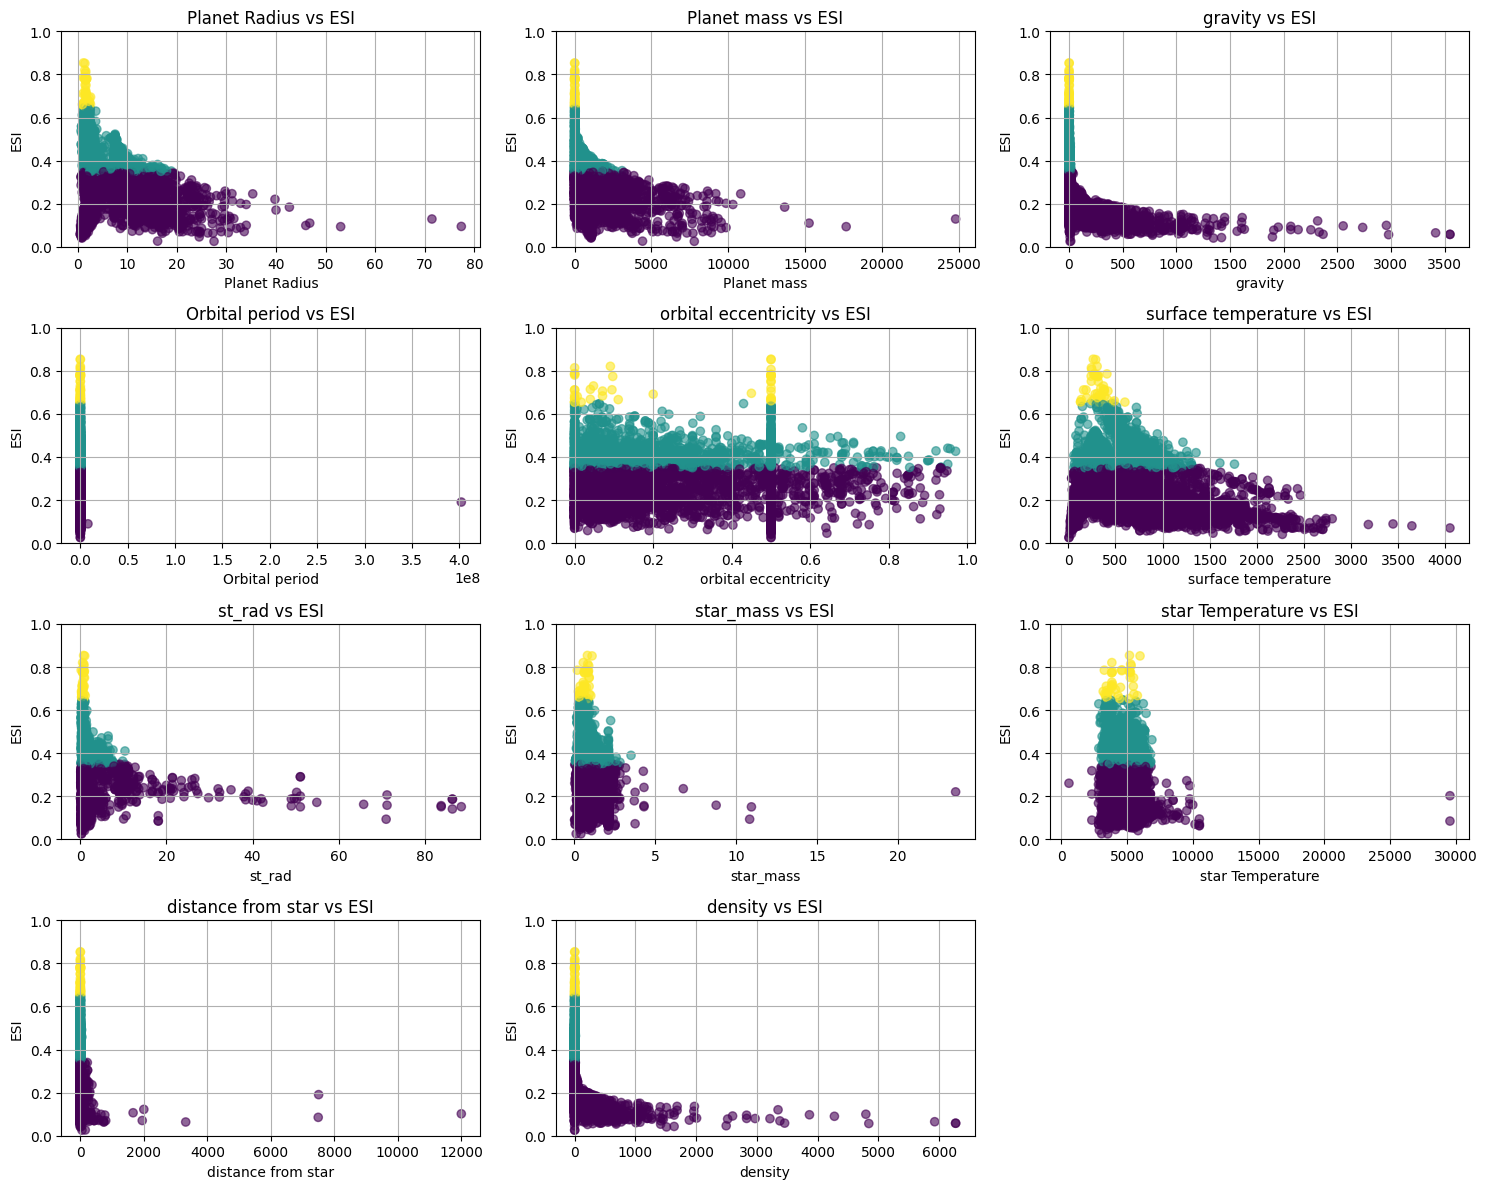

In [159]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("updated_dataset3.csv")

cols = [
    'Planet Radius', 'Planet mass', 'gravity',
    'Orbital period', 'orbital eccentricity',
    'surface temperature', 'st_rad', 'star_mass',
    'star Temperature', 'distance from star',
    'density'
]

df = df.dropna(subset=cols + ['ESI'])

df['esi_cluster'] = pd.cut(
    df['ESI'],
    bins=[0, 0.35, 0.65, 1],
    labels=['Low', 'Medium', 'High']
)

cluster_map = {'Low': 0, 'Medium': 1, 'High': 2}
df['cluster_num'] = df['esi_cluster'].map(cluster_map)


n_cols = 3
n_rows = (len(cols) + 2) // 3

plt.figure(figsize=(15, 12))

for i, col in enumerate(cols):
    plt.subplot(n_rows, n_cols, i + 1)

    plt.scatter(
        df[col],
        df['ESI'],
        c=df['cluster_num'],
        alpha=0.6
    )

    plt.xlabel(col)
    plt.ylabel("ESI")
    plt.title(f"{col} vs ESI")

    plt.ylim(0, 1)
    plt.grid()

plt.tight_layout()
plt.show()

- Dividing the data into test and train data sets

In [174]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import StandardScaler

threshold = data1['ESI'].quantile(0.7)
data1['label'] = (data1['ESI'] >= threshold).astype(int)

X = data1.drop(['Planet Name', 'ESI', 'label'], axis=1)
y = data1['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight='balanced',
    random_state=42
)

model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

new_data = pd.DataFrame([[ 
    1, 0.8, 9.8, 360, 0.01, 288,
    0.9, 0.9, 5770, 1.0, 5.5
]], columns=X.columns)

new_data_scaled = scaler.transform(new_data)

prediction = model.predict(new_data_scaled)
probability = model.predict_proba(new_data_scaled)

print("\nPrediction:", "Habitable" if prediction[0] == 1 else "Not Habitable")
print("Probability:", probability[0])


new_data_original = scaler.inverse_transform(new_data_scaled)
new_planet_full = dict(zip(X.columns, new_data_original[0]))



Accuracy: 0.9619631901840491
              precision    recall  f1-score   support

           0       0.97      0.98      0.97       571
           1       0.95      0.93      0.94       244

    accuracy                           0.96       815
   macro avg       0.96      0.95      0.95       815
weighted avg       0.96      0.96      0.96       815


Prediction: Habitable
Probability: [0.19787619 0.80212381]


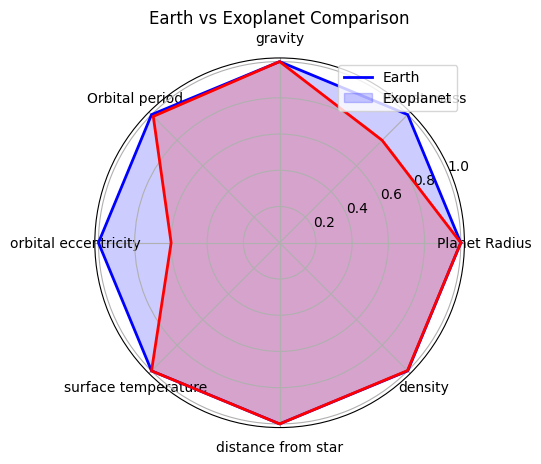

In [175]:
new_planet = {
    'Planet Radius': new_planet_full['Planet Radius'],
    'Planet mass': new_planet_full['Planet mass'],
    'gravity': new_planet_full['gravity'],
    'Orbital period': new_planet_full['Orbital period'],
    'orbital eccentricity': new_planet_full['orbital eccentricity'],
    'surface temperature': new_planet_full['surface temperature'],
    'distance from star': new_planet_full['distance from star'],
    'density': new_planet_full['density']
}


earth = {
    'Planet Radius': 1.0,
    'Planet mass': 1.0,
    'gravity': 9.8,
    'Orbital period': 365,
    'orbital eccentricity': 0.0167,
    'surface temperature': 288,
    'distance from star': 1.0,
    'density': 5.51
}


labels = list(earth.keys())

earth_values = list(earth.values())
new_values = list(new_planet.values())

# Normalize values
max_vals = [max(e, n) for e, n in zip(earth_values, new_values)]
earth_norm = [e/m for e, m in zip(earth_values, max_vals)]
new_norm = [n/m for n, m in zip(new_values, max_vals)]

# Angles
angles = np.linspace(0, 2*np.pi, len(labels), endpoint=False).tolist()

# Close the circle
earth_norm += earth_norm[:1]
new_norm += new_norm[:1]
angles += angles[:1]

plt.figure()

# Earth (blue example)
plt.polar(angles, earth_norm, color='blue', linewidth=2)
plt.fill(angles, earth_norm, color='blue', alpha=0.2)

# New planet (red example)
plt.polar(angles, new_norm, color='red', linewidth=2)
plt.fill(angles, new_norm, color='red', alpha=0.2)

plt.xticks(angles[:-1], labels, rotation=45)

plt.title("Earth vs Exoplanet Comparison")

plt.legend(['Earth', 'Exoplanet'], loc='upper right')

plt.show()

In [ ]:
	Planet Name	Planet Radius	Planet mass	gravity	Orbital period	orbital eccentricity	surface temperature	st_rad	star_mass	star Temperature	distance from star	ESI	density	planet_type
10.540713254356344, 1214.104515, 10.92738, 4799.0, 0.0913, 104.9996, 0.98, 1.015, 5198.0, 5.6, 1.036683238723613	Jovian

1.1, 0.9, 9.8, 365, 0.02, 273,
    1.0, 1.0, 5778, 1.0, 5.5